In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
base_path = "/content/drive/MyDrive/Capstone/Project"
print(os.listdir(base_path))

['Architecture_Diagram.png', 'vmCloud_data.csv', 'boxplot_before.png', 'memory_spike_distribution.png', 'correlation_heatmap.png', 'README.md', '.gitignore', '.git', '.ipynb_checkpoints', 'lstm_training_history.csv', 'preprocessed_data.csv', 'X_train.npy', 'X_val.npy', 'X_test.npy', 'y_train.npy', 'scaler.pkl', 'y_val.npy', 'y_test.npy', 'LSTM_MODEL.ipynb', 'X_train_rf.npy', 'X_val_rf.npy', 'X_test_rf.npy', 'y_train_rf.npy', 'y_val_rf.npy', 'y_test_rf.npy', 'feature_cols_rf.pkl', 'preprocessed_data_rf.csv', 'label_encoders.pkl', 'Memory_Preprocessing.ipynb', 'Data_Modelling.ipynb']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    # Classification
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    # Regression
    r2_score, mean_absolute_error, mean_squared_error
)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print(' Libraries loaded!')

 Libraries loaded!


In [ ]:
PROJECT_FOLDER = '/content/drive/MyDrive/Capstone/Project'
DATASET_PATH   = os.path.join(PROJECT_FOLDER, 'preprocessed_data_rf.csv')

df = pd.read_csv(DATASET_PATH)
print(f' Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

 Loaded: 1999995 rows, 34 columns


,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,hour,dayofweek,dayofmonth,...,memory_lag_5,cpu_lag_1,cpu_lag_2,cpu_lag_3,memory_rate_of_change,memory_pct_change,cpu_rate_of_change,memory_cpu_product,memory_cpu_ratio,memory_spike
0,74.036326,82.890784,253.404369,63.456954,5002.0,42.161191,0.297407,0,6,1,...,49.976089,99.077509,93.148608,14.019569,0.000000,0.000000,0.000000,6136.929072,1.119596,1
1,89.889006,5.710089,453.161356,310.077375,8403.0,14.146201,0.862283,0,6,1,...,89.199261,74.036326,99.077509,93.148608,-77.180695,-0.931113,15.852680,513.274255,0.063524,0
2,50.054758,9.175866,3.881842,247.693806,6263.0,57.264987,0.875892,0,6,1,...,74.367251,89.889006,74.036326,99.077509,3.465777,0.606957,-39.834248,459.295770,0.183317,0
3,23.710173,49.976089,971.309008,114.507997,6029.0,21.798088,0.596863,0,6,1,...,68.979072,50.054758,89.889006,74.036326,40.800223,4.446471,-26.344585,1184.941732,2.107791,0
4,49.506011,86.686656,848.387377,39.412622,3845.0,8.481163,0.500369,0,6,1,...,71.444353,23.710173,50.054758,89.889006,36.710567,0.734563,25.795838,4291.510566,1.751033,1


In [ ]:

EXCLUDE_COLS = [
    'memory_spike',
    'memory_usage',
    'memory_rate_of_change',
    'memory_pct_change',
    'memory_cpu_product',
    'memory_cpu_ratio'
]
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

X_full = df[feature_cols].values
y_cls  = df['memory_spike'].values
y_reg  = df['memory_usage'].values

print(f'Total samples    : {len(X_full)}')
print(f'Total features   : {len(feature_cols)}')
print(f'Class balance    → Normal: {(y_cls==0).sum()}  |  Spike: {(y_cls==1).sum()}')

Total samples    : 1999995
Total features   : 28
Class balance    → Normal: 1599996  |  Spike: 399999


In [ ]:
X_sample   = X_full
y_cls_samp = y_cls
y_reg_samp = y_reg

print(f' dataset → {len(X_full)} samples')
print(f'   Class balance → Normal: {(y_cls==0).sum()}  |  Spike: {(y_cls==1).sum()}')

 dataset → 1999995 samples
   Class balance → Normal: 1599996  |  Spike: 399999


In [ ]:
# # 70% Train | 15% Val | 15% Test
# X_temp_c, X_test_c, y_temp_c, y_test_c = train_test_split(
#     X_sample, y_cls_samp,
#     test_size=0.15, random_state=42, stratify=y_cls_samp
# )
# X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
#     X_temp_c, y_temp_c,
#     test_size=0.15/0.85, random_state=42, stratify=y_temp_c
# )
# print(f'Classification → Train: {len(X_train_c)} | Val: {len(X_val_c)} | Test: {len(X_test_c)}')

n = len(X_sample)

train_end = int(n * 0.7)
val_end   = int(n * 0.85)

X_train_c = X_sample[:train_end]
y_train_c = y_cls_samp[:train_end]

X_val_c = X_sample[train_end:val_end]
y_val_c = y_cls_samp[train_end:val_end]

X_test_c = X_sample[val_end:]
y_test_c = y_cls_samp[val_end:]

print(f'Classification → Train: {len(X_train_c)} | Val: {len(X_val_c)} | Test: {len(X_test_c)}')

Classification → Train: 1399996 | Val: 299999 | Test: 300000


In [ ]:
# Train RandomForestClassifier
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_c, y_train_c)
print(' RandomForestClassifier trained!')

 RandomForestClassifier trained!


In [ ]:
import pandas as pd

feature_importance = pd.Series(
    rf_clf.feature_importances_,
    index=df[feature_cols].columns
).sort_values(ascending=False)

print(feature_importance.head(10))

memory_roll_max_5      0.292976
memory_roll_mean_5     0.166617
memory_lag_1           0.104669
memory_lag_2           0.099496
memory_lag_3           0.098919
memory_roll_std_5      0.088957
memory_roll_mean_10    0.043795
memory_lag_5           0.007959
power_consumption      0.006794
network_traffic        0.006772
dtype: float64


In [ ]:
# Evaluate Classification
y_pred_c      = rf_clf.predict(X_test_c)
y_pred_proba  = rf_clf.predict_proba(X_test_c)[:, 1]

acc       = accuracy_score(y_test_c,  y_pred_c)
precision = precision_score(y_test_c, y_pred_c, zero_division=0)
recall    = recall_score(y_test_c,    y_pred_c, zero_division=0)
f1        = f1_score(y_test_c,        y_pred_c, zero_division=0)
roc_auc   = roc_auc_score(y_test_c,  y_pred_proba)

print('=' * 50)
print(' CLASSIFICATION RESULTS (memory_spike)')
print('=' * 50)
print(f'  Accuracy  : {acc:.4f}   ({acc*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('=' * 50)
print()
print(' Full Classification Report (Test):')
print(classification_report(y_test_c, y_pred_c, target_names=['Normal (0)', 'Spike (1)']))

# ── Validation check (catch overfitting) ──
y_pred_val_c = rf_clf.predict(X_val_c)
val_acc = accuracy_score(y_val_c, y_pred_val_c)
val_f1  = f1_score(y_val_c, y_pred_val_c, zero_division=0)
print(' Validation Check:')
print(f'  Val Accuracy : {val_acc:.4f}  |  Test Accuracy : {acc:.4f}')
print(f'  Val F1-Score : {val_f1:.4f}  |  Test F1-Score : {f1:.4f}')
if abs(val_acc - acc) > 0.05:
    print('  Gap > 5% — possible overfitting!')
else:
    print('  Val and Test scores are close — model is stable.')

 CLASSIFICATION RESULTS (memory_spike)
  Accuracy  : 0.8315   (83.15%)
  Precision : 0.5465
  Recall    : 0.9192
  F1-Score  : 0.6855
  ROC-AUC   : 0.9134

 Full Classification Report (Test):
              precision    recall  f1-score   support

  Normal (0)       0.98      0.81      0.88    240056
   Spike (1)       0.55      0.92      0.69     59944

    accuracy                           0.83    300000
   macro avg       0.76      0.86      0.79    300000
weighted avg       0.89      0.83      0.85    300000

 Validation Check:
  Val Accuracy : 0.8321  |  Test Accuracy : 0.8315
  Val F1-Score : 0.6873  |  Test F1-Score : 0.6855
  Val and Test scores are close — model is stable.


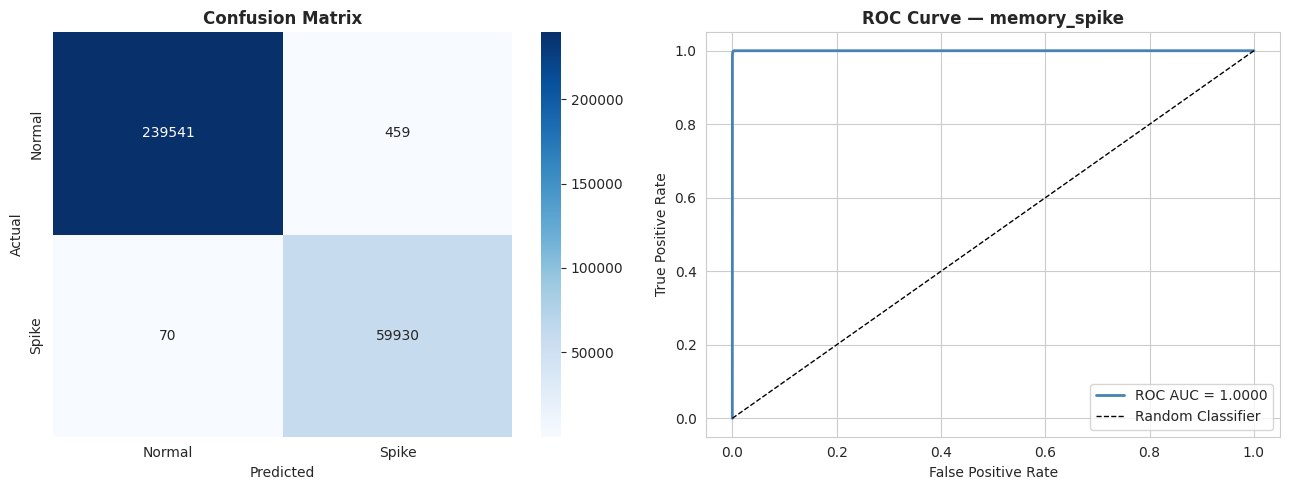

In [ ]:
# Confusion Matrix + ROC Curve
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Spike'],
            yticklabels=['Normal', 'Spike'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test_c, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
axes[1].set_title('ROC Curve — memory_spike', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('rf_classification_results.png', dpi=120, bbox_inches='tight')
plt.show()